# Function numpy yang akan digunakan dalam Gauss-Seidel
1. np.array() -> mengubah list menjadi array
2. np.diag() -> mencari nilai diagonal dari sebuah array
3. np.abs() -> mengabsolutkan value
4. np.fill_diagonal() -> fill value diagonal dari sebuah array
5. np.sum() -> melakukan penjumlahan
6. np.all() -> melakukan test pada semua element dalam array
7. np.zeros() -> return sebuah array yang berisi nilai 0 semua
8. np.dot() -> melakukan perkalian antar matrix
9. np.sqrt() -> melakukan pengakaran

# Function Gauss-Seidel

In [ ]:
# TODO: import numpy library
import numpy as np

# TODO: buat function untuk cek diagonally dominant
def isDiagonallyDominant(x): #to check if its diagonally dominant
    x = np.array(x) #change it into an array
    if x.ndim != 2 or x.shape[0] != x.shape[1]: #x.ndim != 2 ensures that the matrix is 2D, x.shape[0] != x.shape[1] ensures that it's a square matrix. DIAGONALLY DOMINANCE IS ONLY DEFINED AT SQUARE MATRICES.
        return False
    x = np.abs(x) #change every value in the matrix into absolute
    diag = np.diag(x) #it just takes the diagonal
    off_diag = np.sum(x, axis=1) - diag #axis=1 to take one row, sum all in one row and subtract it with the diagonal
    return np.all(diag > off_diag) #check if the diagonal is larger than the off-diagonal

# TODO: buat function gauss-seidel
def gauss_seidel(A, b, threshold=0.01, t=15):
    print(f"A: {A}, b: {b}")
    if not isDiagonallyDominant(A):
        print("Matrix is not diagonally dominant.\n")
        return
    
    #change the list into an array
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    
    diag = np.diag(A) #take the diagonal for division
    A = -A #negate A
    np.fill_diagonal(A, 0) #fill diagonal A with 0 so the multiplication works (the result gotta be 0)
    
    x_old = np.zeros(A.shape[0]) #[x1, x2, x3] = [0, 0, 0]
    
    #iteration based on max iteration (t)
    for i in range(t):
        x_new = np.array(x_old) #copy the old x to the new x
        
        for idx, row in enumerate(A):
            x_new[idx] = (b[idx] + np.dot(row, x_new)) / diag[idx]
            
        print(f"Iteration: {i + 1}", x_new)
        
        #threshold check
        dx = np.sqrt(np.dot(x_new - x_old, x_new - x_old))
        if dx < threshold:
            print("Convergent.\n")
            return
        
        x_old = x_new
        
    print("Not convergent.\n")


# Case saat hanya ada 1 persamaan
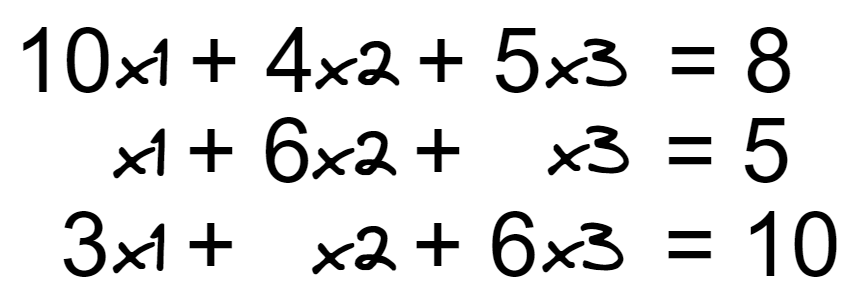

In [ ]:
# Snippet persamaan
Xs = [
    [10, 4, 5],
    [1, 6, 1],
    [3, 1, 6]
]

Ys = [8, 5, 10]

# TODO: implement function gauss-seidel untuk 1 persamaan
gauss_seidel(Xs, Ys)


# Case saat lebih dari 1 persamaan

##Persamaan 1
>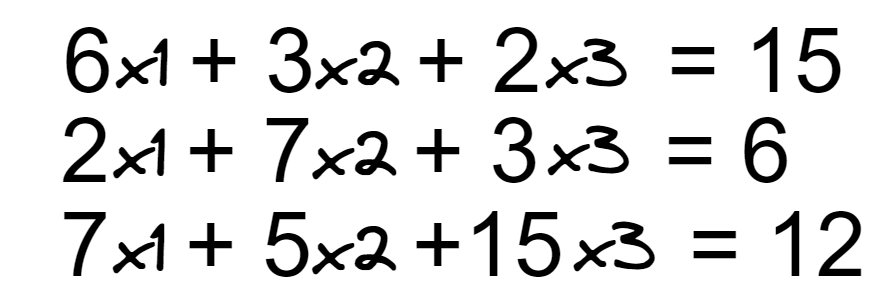

##Persamaan 2
> 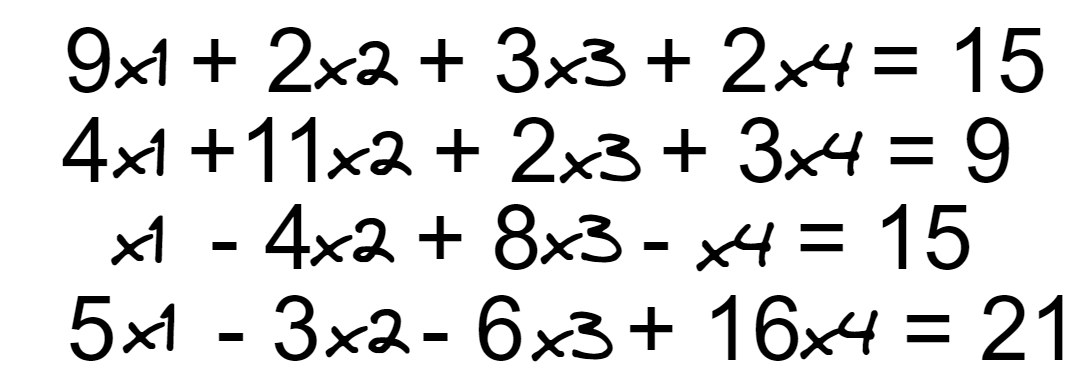

In [ ]:
# Snippet persamaan
Xm = [
    # Persamaan 1
    [
      [6, 3, 2],
      [2, 7, 3],
      [7, 5, 15]
    ],
    # Persamaan 2
    [
      [9, 2, 3, 2],
      [4, 11, 2, 3],
      [1, -4, 8, -1],
      [5, -3, -6, 16],
    ]
]

Ym = [
    # Hasil dari persamaan 1
    [8, 5, 10],
    # Hasil dari persamaan 2
    [15, 9, 15, 21]
]

# TODO: implement function gauss-seidel untuk persamaan yang lebih dari 1
for i, (X, Y) in enumerate(zip(Xm, Ym)):
  print(f"Persamaan - ", i)
  gauss_seidel(X, Y)
  print(" ")